In [65]:
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from scipy.stats import uniform

In [66]:
df = pd.read_csv("../Dataset/final_selected_dataset.csv")

df.head()

,final_result,registration_days,avg_activity_day,login_frequency,video_clicks,avg_quiz_score,avg_submission_day,assessments_completed,avg_assessment_weight,studied_credits,code_module,gender,code_presentation,highest_education,age_band,dropout
0,Pass,270.0,102.132653,196.0,934.0,78.0,18.0,1.0,10.0,240,AAA,M,2013J,HE Qualification,55<=,0
1,Pass,270.0,86.993023,430.0,1435.0,70.0,22.0,1.0,10.0,60,AAA,F,2013J,HE Qualification,35-55,0
2,Withdrawn,104.0,2.355263,76.0,281.0,0.0,0.0,0.0,0.0,60,AAA,F,2013J,A Level or Equivalent,35-55,1
3,Pass,270.0,106.147813,663.0,2158.0,72.0,17.0,1.0,10.0,60,AAA,F,2013J,A Level or Equivalent,35-55,0
4,Pass,270.0,91.934659,352.0,1034.0,69.0,26.0,1.0,10.0,60,AAA,F,2013J,Lower Than A Level,0-35,0


In [67]:
print(df.shape)

df.info()

(32593, 16)
<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   final_result           32593 non-null  str    
 1   registration_days      32593 non-null  float64
 2   avg_activity_day       32593 non-null  float64
 3   login_frequency        32593 non-null  float64
 4   video_clicks           32593 non-null  float64
 5   avg_quiz_score         32593 non-null  float64
 6   avg_submission_day     32593 non-null  float64
 7   assessments_completed  32593 non-null  float64
 8   avg_assessment_weight  32593 non-null  float64
 9   studied_credits        32593 non-null  int64  
 10  code_module            32593 non-null  str    
 11  gender                 32593 non-null  str    
 12  code_presentation      32593 non-null  str    
 13  highest_education      32593 non-null  str    
 14  age_band               32593 non-null  str    
 15  d

In [68]:
# Remove Unwanted Columns
if "final_result" in df.columns:
    df = df.drop(columns=["final_result"])

df.head()

,registration_days,avg_activity_day,login_frequency,video_clicks,avg_quiz_score,avg_submission_day,assessments_completed,avg_assessment_weight,studied_credits,code_module,gender,code_presentation,highest_education,age_band,dropout
0,270.0,102.132653,196.0,934.0,78.0,18.0,1.0,10.0,240,AAA,M,2013J,HE Qualification,55<=,0
1,270.0,86.993023,430.0,1435.0,70.0,22.0,1.0,10.0,60,AAA,F,2013J,HE Qualification,35-55,0
2,104.0,2.355263,76.0,281.0,0.0,0.0,0.0,0.0,60,AAA,F,2013J,A Level or Equivalent,35-55,1
3,270.0,106.147813,663.0,2158.0,72.0,17.0,1.0,10.0,60,AAA,F,2013J,A Level or Equivalent,35-55,0
4,270.0,91.934659,352.0,1034.0,69.0,26.0,1.0,10.0,60,AAA,F,2013J,Lower Than A Level,0-35,0


In [69]:
# Feature Engineering

df["engagement_score"] = (
    df["login_frequency"] +
    df["video_clicks"] +
    df["avg_activity_day"]
) / 3

df["activity_per_login"] = (
    df["video_clicks"] /
    (df["login_frequency"] + 1)
)

df["quiz_completion"] = (
    df["avg_quiz_score"] *
    df["assessments_completed"]
)

df["submission_consistency"] = (
    df["avg_submission_day"] /
    (df["assessments_completed"] + 1)
)

print(df.head())

   registration_days  avg_activity_day  login_frequency  video_clicks  \
0              270.0        102.132653            196.0         934.0   
1              270.0         86.993023            430.0        1435.0   
2              104.0          2.355263             76.0         281.0   
3              270.0        106.147813            663.0        2158.0   
4              270.0         91.934659            352.0        1034.0   

   avg_quiz_score  avg_submission_day  assessments_completed  \
0            78.0                18.0                    1.0   
1            70.0                22.0                    1.0   
2             0.0                 0.0                    0.0   
3            72.0                17.0                    1.0   
4            69.0                26.0                    1.0   

   avg_assessment_weight  studied_credits code_module gender  \
0                   10.0              240         AAA      M   
1                   10.0               60       

In [70]:
# Separate Features and Target
X = df.drop(
    columns=[
        "dropout",
        "registration_days"
    ],
    errors="ignore"
)
y = df["dropout"]

In [71]:
# Identify Categorical Columns
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(categorical_features)

['code_module', 'gender', 'code_presentation', 'highest_education', 'age_band']


C:\Users\saran\AppData\Local\Temp\ipykernel_940\2416283405.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [72]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [73]:
df["dropout"].value_counts()

dropout
0    22437
1    10156
Name: count, dtype: int64

In [74]:
df = pd.read_csv("../Dataset/final_dataset.csv")

print(df["dropout"].value_counts())

dropout
0    22437
1    10156
Name: count, dtype: int64


In [75]:
df["dropout"].value_counts()
df.head()
import pandas as pd

studentInfo = pd.read_csv("../Dataset/processed/studentInfo_clean.csv")

studentInfo["final_result"].value_counts()
studentInfo["final_result"].unique()

<StringArray>
['Pass', 'Withdrawn', 'Fail', 'Distinction']
Length: 4, dtype: str

In [76]:
studentInfo["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [77]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

cat_model = CatBoostClassifier(

    loss_function="Logloss",

    eval_metric="AUC",

    random_seed=42,

    verbose=0

)

In [78]:
model = CatBoostClassifier(

    iterations=1500,

    learning_rate=0.03,

    depth=8,

    l2_leaf_reg=5,

    random_strength=1,

    bagging_temperature=1,

    loss_function="Logloss",

    eval_metric="AUC",

    random_seed=42,

    verbose=100

)

model.fit(

    X_train,

    y_train,

    cat_features=categorical_features,

    eval_set=(X_test, y_test),

    early_stopping_rounds=100,

    use_best_model=True

)

0:	test: 0.9100273	best: 0.9100273 (0)	total: 129ms	remaining: 3m 14s
100:	test: 0.9375870	best: 0.9375870 (100)	total: 10.8s	remaining: 2m 29s
200:	test: 0.9386373	best: 0.9386392 (196)	total: 21.2s	remaining: 2m 16s
300:	test: 0.9387565	best: 0.9387565 (300)	total: 31.7s	remaining: 2m 6s
400:	test: 0.9389804	best: 0.9389804 (400)	total: 42.2s	remaining: 1m 55s
500:	test: 0.9389948	best: 0.9390452 (428)	total: 53.6s	remaining: 1m 46s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9390452334
bestIteration = 428

Shrink model to first 429 iterations.


CatBoostClassifier(bagging_temperature=1, depth=8, eval_metric='AUC', iterations=1500, l2_leaf_reg=5, learning_rate=0.03, loss_function='Logloss', random_seed=42, random_strength=1, verbose=100)

In [79]:
model.fit(

    X_train,

    y_train,

    cat_features=categorical_features,

    eval_set=(X_test,y_test),

    early_stopping_rounds=100,

    use_best_model=True

)

0:	test: 0.9100273	best: 0.9100273 (0)	total: 107ms	remaining: 2m 40s
100:	test: 0.9375870	best: 0.9375870 (100)	total: 10.8s	remaining: 2m 29s
200:	test: 0.9386373	best: 0.9386392 (196)	total: 21.2s	remaining: 2m 16s
300:	test: 0.9387565	best: 0.9387565 (300)	total: 32s	remaining: 2m 7s
400:	test: 0.9389804	best: 0.9389804 (400)	total: 42.5s	remaining: 1m 56s
500:	test: 0.9389948	best: 0.9390452 (428)	total: 53.9s	remaining: 1m 47s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9390452334
bestIteration = 428

Shrink model to first 429 iterations.


CatBoostClassifier(bagging_temperature=1, depth=8, eval_metric='AUC', iterations=1500, l2_leaf_reg=5, learning_rate=0.03, loss_function='Logloss', random_seed=42, random_strength=1, verbose=100)

In [80]:
# Prediction
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [81]:
# Accuracy
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.8628624022089277


In [82]:
print(df["dropout"].value_counts())
print(df["dropout"].value_counts(normalize=True))

dropout
0    22437
1    10156
Name: count, dtype: int64
dropout
0    0.688399
1    0.311601
Name: proportion, dtype: float64


In [83]:
print(X.columns.tolist())

['avg_activity_day', 'login_frequency', 'video_clicks', 'avg_quiz_score', 'avg_submission_day', 'assessments_completed', 'avg_assessment_weight', 'studied_credits', 'code_module', 'gender', 'code_presentation', 'highest_education', 'age_band', 'engagement_score', 'activity_per_login', 'quiz_completion', 'submission_consistency']


In [84]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Training Accuracy :", accuracy_score(y_train, train_pred))
print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

Training Accuracy : 0.8814911405998312
Testing Accuracy  : 0.8628624022089277


In [85]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                   Feature  Importance
0         avg_activity_day   45.468097
8              code_module    7.179750
10       code_presentation    6.539821
7          studied_credits    4.762288
1          login_frequency    4.684393
13        engagement_score    3.505570
2             video_clicks    3.459149
11       highest_education    3.145040
14      activity_per_login    2.798203
16  submission_consistency    2.715917
6    avg_assessment_weight    2.684644
12                age_band    2.661208
15         quiz_completion    2.555929
3           avg_quiz_score    2.495291
9                   gender    2.380054
4       avg_submission_day    2.171243
5    assessments_completed    0.793405


In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8628624022089277
Precision : 0.7737120847376023
Recall : 0.7912358444116199
F1 Score : 0.7823758519961052
ROC AUC : 0.9390452333746712

Confusion Matrix
[[4018  470]
 [ 424 1607]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      4488
           1       0.77      0.79      0.78      2031

    accuracy                           0.86      6519
   macro avg       0.84      0.84      0.84      6519
weighted avg       0.86      0.86      0.86      6519



In [87]:
import shap

c:\Users\saran\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [88]:
explainer = shap.TreeExplainer(model)

In [89]:
shap_values = explainer.shap_values(X_test)

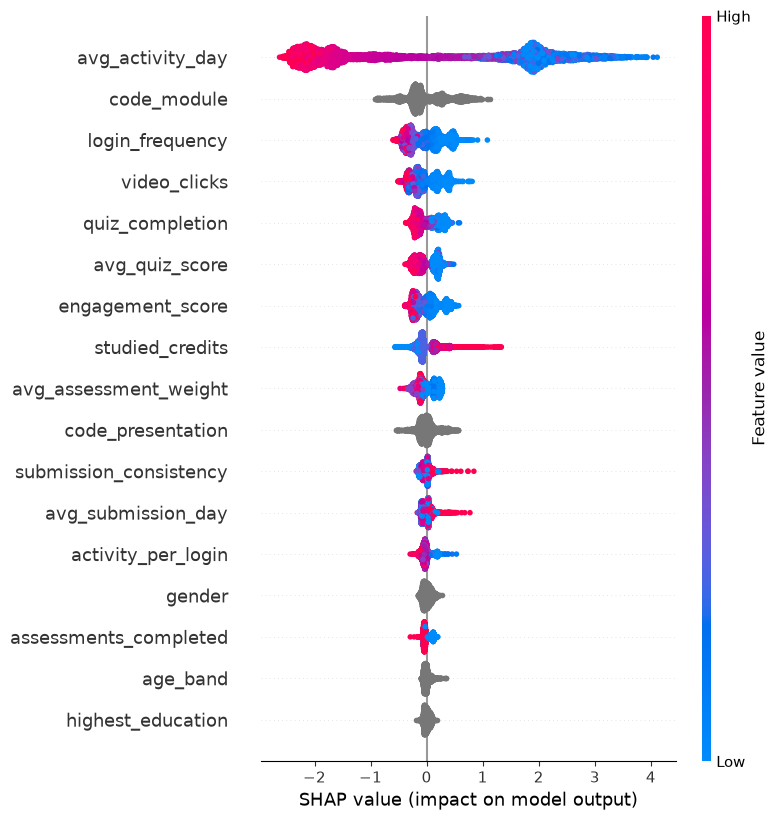

In [90]:
shap.summary_plot(
    shap_values,
    X_test
)

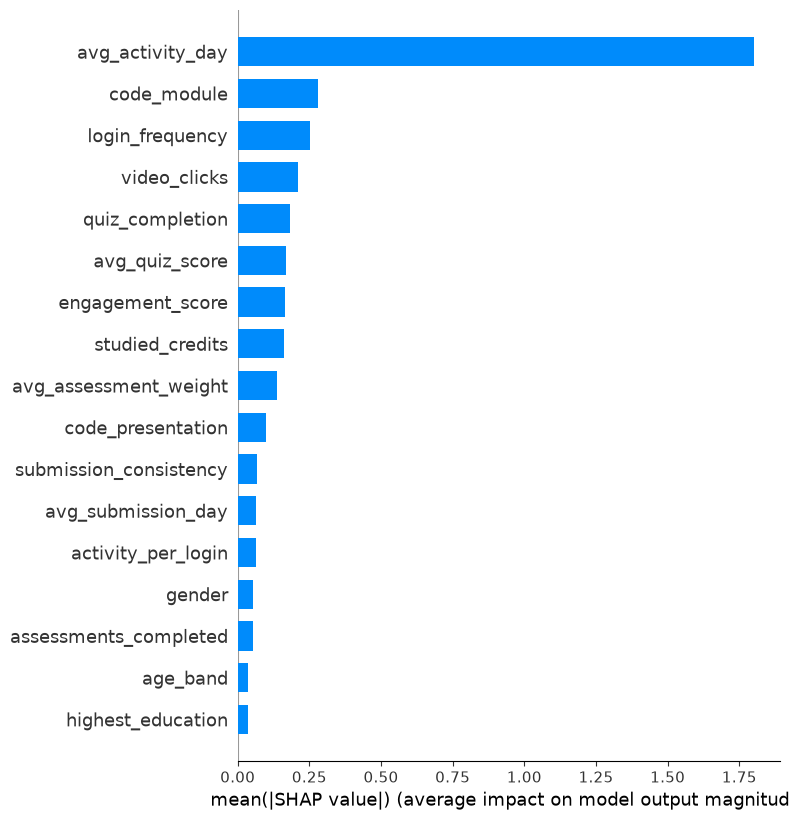

In [91]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [92]:
risk_probability = model.predict_proba(X_test)[:,1]

In [93]:
# Predict for ALL students

all_predictions = model.predict(X)

all_probabilities = model.predict_proba(X)[:, 1]


# Risk Level Function

def classify_risk(prob):

    if prob < 0.30:
        return "Low"

    elif prob < 0.70:
        return "Medium"

    else:
        return "High"


risk_level = [classify_risk(p) for p in all_probabilities]


# Create Result Dataset

results = X.copy()

results.insert(0, "Student ID", range(1, len(results)+1))

results["Actual"] = y.values

results["Predicted"] = all_predictions.astype(int)

results["Risk Probability"] = all_probabilities

results["Risk Level"] = risk_level


print(results.head())

print(results.shape)


results.to_csv(
    "../Dataset/student_risk_prediction.csv",
    index=False
)

print("Student Risk Prediction Dataset Saved Successfully")

   Student ID  avg_activity_day  login_frequency  video_clicks  \
0           1        102.132653            196.0         934.0   
1           2         86.993023            430.0        1435.0   
2           3          2.355263             76.0         281.0   
3           4        106.147813            663.0        2158.0   
4           5         91.934659            352.0        1034.0   

   avg_quiz_score  avg_submission_day  assessments_completed  \
0            78.0                18.0                    1.0   
1            70.0                22.0                    1.0   
2             0.0                 0.0                    0.0   
3            72.0                17.0                    1.0   
4            69.0                26.0                    1.0   

   avg_assessment_weight  studied_credits code_module  ...  \
0                   10.0              240         AAA  ...   
1                   10.0               60         AAA  ...   
2                    0.0        

In [94]:
print(results.shape)

(32593, 22)


In [95]:
print("df shape :", df.shape)

print("X shape :", X.shape)

print("y shape :", y.shape)

print(df.columns)

df shape : (32593, 20)
X shape : (32593, 17)
y shape : (32593,)
Index(['code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'dropout',
       'avg_quiz_score', 'assessments_completed', 'avg_assessment_weight',
       'avg_submission_day', 'video_clicks', 'login_frequency',
       'avg_activity_day', 'registration_days'],
      dtype='str')


In [96]:
print(pd.read_csv("../Dataset/final_selected_dataset.csv").shape)

print(pd.read_csv("../Dataset/final_dataset.csv").shape)

print(pd.read_csv("../Dataset/final_dataset.csv").columns)

(32593, 16)
(32593, 20)
Index(['code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'dropout',
       'avg_quiz_score', 'assessments_completed', 'avg_assessment_weight',
       'avg_submission_day', 'video_clicks', 'login_frequency',
       'avg_activity_day', 'registration_days'],
      dtype='str')
